In [1]:
"""
Segmentación por watershed
Este notebook presenta la segmentación por watershed para separar objetos que se tocan o se superponen en imágenes binarias.
El etiquetado de componentes conectados funciona bien cuando los objetos están claramente separados, pero falla cuando las regiones vecinas se fusionan en un único componente conectado. 
La segmentación por watershed ayuda a resolver este problema dividiendo las regiones fusionadas mediante conceptos topográficos y segmentación basada en marcadores.
Objetivos de aprendizaje
- Comprender por qué fallan los componentes conectados para objetos que se tocan.
- Interpretar conceptualmente la segmentación por watershed.
- Utilizar la transformada de distancia para identificar los centros de los objetos.
- Crear marcadores para la segmentación por watershed.
- Separar los objetos fusionados en regiones individuales.
- Comparar la segmentación antes y después de la segmentación por watershed.
Contexto de la imagen reales
La segmentación por watershed se utiliza ampliamente en la imagen para:
- Separar partículas que se tocan.
- Separar poros o granos fusionados.
- Segmentación de células y núcleos.
- Conteo de objetos en imágenes con alta densidad de objetos.
- Mejorar el análisis cuantitativo basado en regiones.
"""

'\nSegmentación por watershed\nEste notebook presenta la segmentación por watershed para separar objetos que se tocan o se superponen en imágenes binarias.\nEl etiquetado de componentes conectados funciona bien cuando los objetos están claramente separados, pero falla cuando las regiones vecinas se fusionan en un único componente conectado. \nLa segmentación por watershed ayuda a resolver este problema dividiendo las regiones fusionadas mediante conceptos topográficos y segmentación basada en marcadores.\nObjetivos de aprendizaje\n- Comprender por qué fallan los componentes conectados para objetos que se tocan.\n- Interpretar conceptualmente la segmentación por watershed.\n- Utilizar la transformada de distancia para identificar los centros de los objetos.\n- Crear marcadores para la segmentación por watershed.\n- Separar los objetos fusionados en regiones individuales.\n- Comparar la segmentación antes y después de la segmentación por watershed.\nContexto de la imagen reales\nLa segme

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import ndimage as ndi

from skimage import data, filters, measure, morphology, segmentation, feature, color, util
from skimage.draw import disk

In [3]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

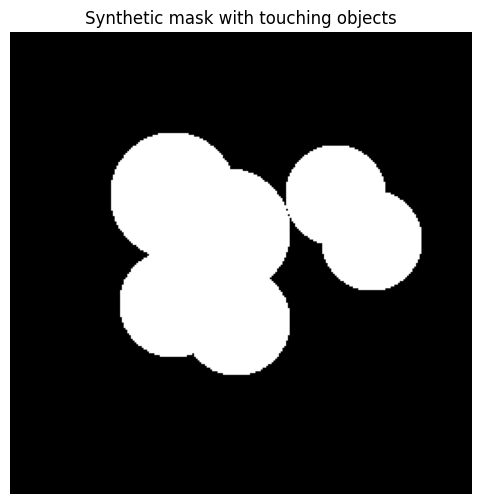

In [4]:
mask = np.zeros((256, 256), dtype=bool)

disks = [
    ((90, 90), 35),
    ((110, 120), 35),
    ((150, 90), 30),
    ((160, 125), 30),
    ((90, 180), 28),
    ((115, 200), 28),
]

for center, radius in disks:
    rr, cc = disk(center, radius, shape=mask.shape)
    mask[rr, cc] = True

show_image(
    mask,
    "Synthetic mask with touching objects",
    save_path="../figures/figures_watershed_segmentation/synthetic_touching_objects.png"
)

Numero de Componentes conectados antes de la división por watershed: 1


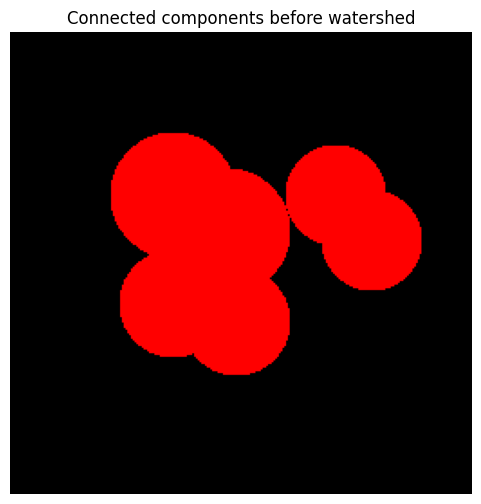

In [8]:
"""
Componentes conectados antes de la división por watershed
Si etiquetamos directamente la máscara binaria, los objetos que se tocan se agrupan en regiones conectadas fusionadas.
"""
labels_before = measure.label(mask, connectivity=2)

print(f"Numero de Componentes conectados antes de la división por watershed: {labels_before.max()}")

show_image(
    color.label2rgb(labels_before, bg_label=0),
    "Connected components before watershed",
    cmap=None,
    save_path="../figures/watershed_segmentation/connected_components_before_watershed.png"
)


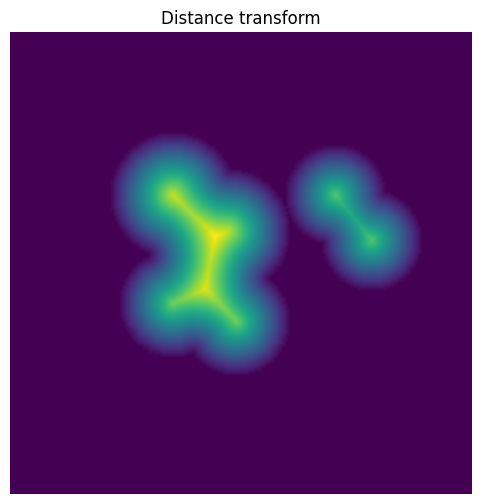

In [9]:
"""
Transformada de la distancia
Una estrategia común de segmentación por watershed para máscaras binarias consiste en calcular la transformada de la distancia.
Para cada píxel de primer plano, la transformada de la distancia mide la distancia al píxel de fondo más cercano.
Los centros de los objetos suelen tener valores de distancia mayores, por lo que el mapa de distancia ayuda a identificar posibles interiores de objetos.
"""
distance_map = ndi.distance_transform_edt(mask)

show_image(
    distance_map,
    "Distance transform",
    cmap="viridis",
    save_path="../figures/figures_watershed_segmentation/distance_transform.png"
)

Numero de marcadores: 5


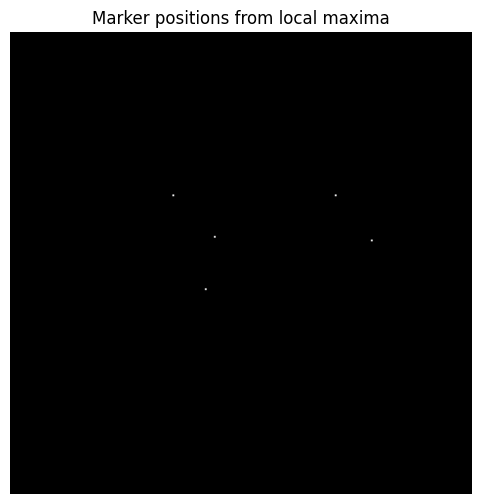

In [11]:
"""
Detección de máximos locales como marcadores
Para aplicar el algoritmo de segmentación por cuencas hidrográficas, necesitamos marcadores que representen los centros probables de los objetos.
Un enfoque común consiste en detectar los máximos locales en el mapa de distancias.
"""
coords = feature.peak_local_max(
    distance_map,
    labels=mask,
    footprint=np.ones((25, 25))
)

marker_mask = np.zeros(distance_map.shape, dtype=bool)
marker_mask[tuple(coords.T)] = True

markers, _ = ndi.label(marker_mask)

print(f"Numero de marcadores: {markers.max()}")

show_image(
    marker_mask,
    "Marker positions from local maxima",
    save_path="../figures/figures_watershed_segmentation/marker_positions.png"
)

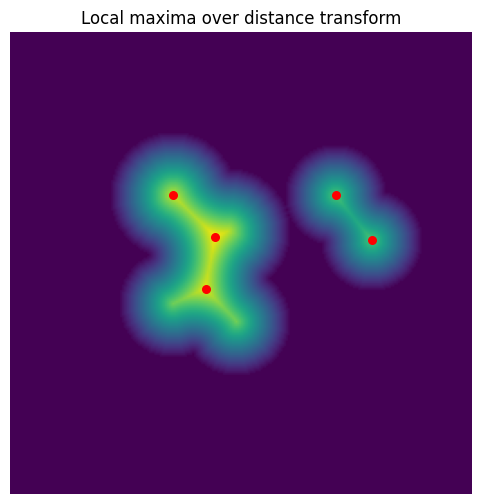

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(distance_map, cmap="viridis")
ax.scatter(coords[:, 1], coords[:, 0], s=30, c="red")
ax.set_title("Local maxima over distance transform")
ax.axis("off")

os.makedirs("../figures/watershed_segmentation", exist_ok=True)
plt.savefig(
    "../figures/watershed_segmentation/local_maxima_over_distance_map.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

Number of objects after watershed: 5


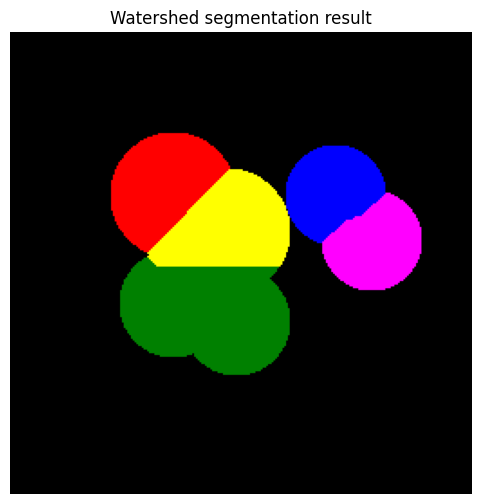

In [13]:
"""
Segmentación por watershed
Ahora, el algoritmo de watershed puede generar regiones a partir de los marcadores.
Al usar el mapa de distancia negativa, los centros de los objetos actúan como cuencas, por lo que la segmentación se expande hacia afuera hasta que las regiones vecinas se encuentran.
"""
labels_ws = segmentation.watershed(-distance_map, markers, mask=mask)

print(f"Number of objects after watershed: {labels_ws.max()}")

show_image(
    color.label2rgb(labels_ws, bg_label=0),
    "Watershed segmentation result",
    cmap=None,
    save_path="../figures/watershed_segmentation/watershed_result.png"
)